In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
import seaborn as sns
import os
import shlex
import sys
from joblib import load
import glob 
import re


## loss and accuracy

In [2]:
'results_pretrained_ventral-cnn-mse_hsize-1024_input-both_logpolar_num3-7_nl-0.74_policy-cheat+jitter_trainshapes-BCDE_min_logpolar_12_100000_loss-num_opt-Adam_drop0.5_sort_count-notA_300eps_rep0' \
== \
'results_pretrained_ventral-cnn-mse_hsize-1024_input-both_logpolar_num3-7_nl-0.74_policy-cheat+jitter_trainshapes-BCDE_min_logpolar_12_100000_loss-num_opt-Adam_drop0.5_sort_count-notA_300eps_rep0'


True

In [3]:
res_dirs = ["Results_samenonminshape/results/logpolar",
            "Results_nojittersamenonminshape/results/logpolar"]
res_files = [glob.glob(os.path.join(res_dir, "results_*.pkl")) for res_dir in res_dirs]
res_files = sum(res_files, [])  # flatten list of lists


In [4]:
res_lists = {}
shortmodelnames = dict(zip(res_dirs,
                           ["jitters", "nojitters"]))
for rd,rf in zip(res_dirs, res_files):
    res = load(rf)
    res["dataset"] = pd.Categorical(res["dataset"], categories = ["train","validation","ood"],ordered=True)
    taskname = "SameNonMinShape"
    saccond = shortmodelnames[rd]
    res_lists[f"{taskname}, sac-{saccond}"] = res
        
    
# we have 300+1 epochs in total
loss_cols = ['count map loss','count num loss','dist map loss']
acc_cols = ['accuracy count']

res.columns

Index(['full map loss', 'dist map loss', 'count map loss', 'count num loss',
       'dist num loss', 'all num loss', 'shape loss', 'accuracy count',
       'accuracy dist', 'accuracy all', 'epoch', 'dataset', 'accuracy map',
       'viewing', 'test shapes', 'test lums'],
      dtype='object')

In [5]:
list(res_lists.keys())

['SameNonMinShape, sac-jitters', 'SameNonMinShape, sac-nojitters']

In [6]:
dsdf = res[res['dataset']=='ood'].copy()
dsdf['test shapes'].unique()

array(["['C', 'F', 'G', 'H', 'J']", "['B', 'C', 'D', 'E']"], dtype=object)

/tmp/ipykernel_124662/2836408669.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for j, (ds, dsdf) in enumerate(res.groupby('dataset')):
/tmp/ipykernel_124662/2836408669.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for j, (ds, dsdf) in enumerate(res.groupby('dataset')):


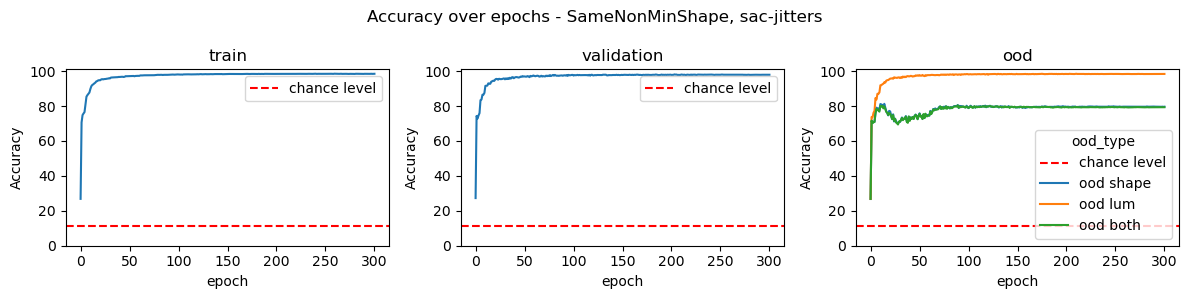

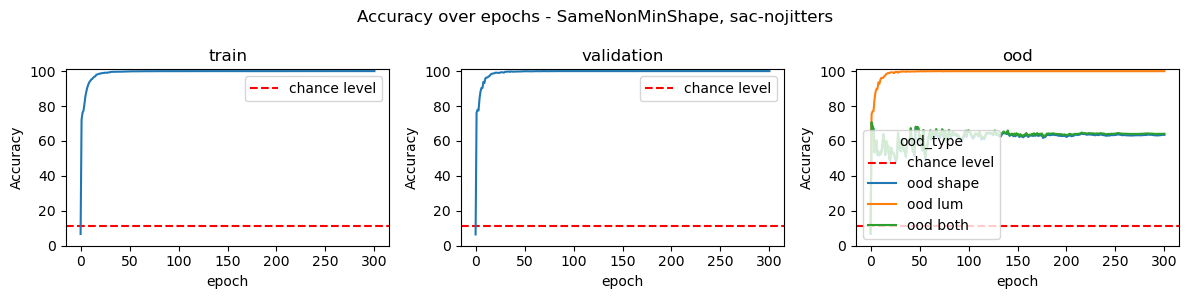

In [7]:
for rsname, res in res_lists.items():
    fig_acc, ax_acc = plt.subplots(1,3, figsize=(3*4, 3))
    for j, (ds, dsdf) in enumerate(res.groupby('dataset')):
        if "1-7" in rsname:
            chance_level = 100 * (1/7)
        else:
            chance_level = 100 * (1/9)
        ax_acc[j].axhline(chance_level, color='red', linestyle='--', label='chance level')
        
        if ds == "ood":
            # further split by test shapes and lums
            dsdf = dsdf.copy()
            dsdf['test shapes ood'] = [s == "['C', 'F', 'G', 'H', 'J']" for s in dsdf['test shapes']]
            dsdf['test lums ood'] = [l == "[0.3, 0.6, 0.9]" for l in dsdf['test lums']]
            dsdf['ood_type'] = ["ood shape" if np.logical_and(s, not l) else
                                "ood lum" if np.logical_and(not s, l) else
                                "ood both" if np.logical_and(s, l) else
                                "iid" for s, l in zip(dsdf['test shapes ood'], dsdf['test lums ood'])]
            sns.lineplot(data=dsdf, x='epoch', y='accuracy count', hue='ood_type', ax=ax_acc[j])
            

        else:
            sns.lineplot(data=dsdf, x='epoch', y='accuracy count', ax=ax_acc[j])
        
        ax_acc[j].set_ylim(0, 101)        
        ax_acc[j].set_title(ds)
        ax_acc[j].set_ylabel('Accuracy')

    fig_acc.suptitle(f'Accuracy over epochs - {rsname}')
    plt.tight_layout()

/tmp/ipykernel_124662/663362577.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for j, (ds, dsdf) in enumerate(res.groupby('dataset')):
/tmp/ipykernel_124662/663362577.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for j, (ds, dsdf) in enumerate(res.groupby('dataset')):


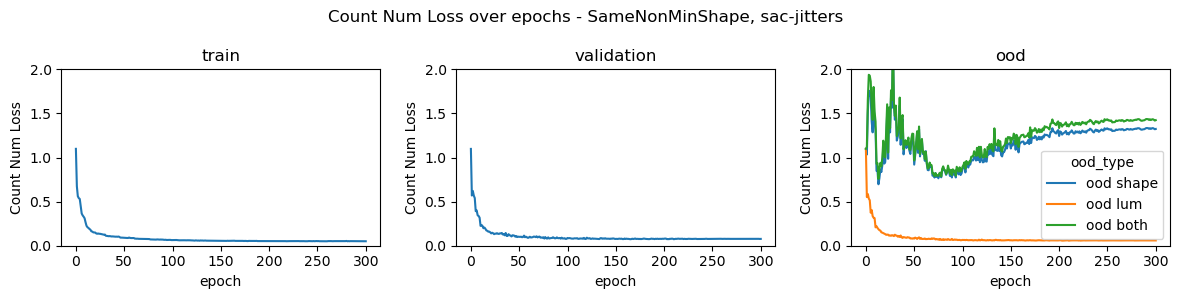

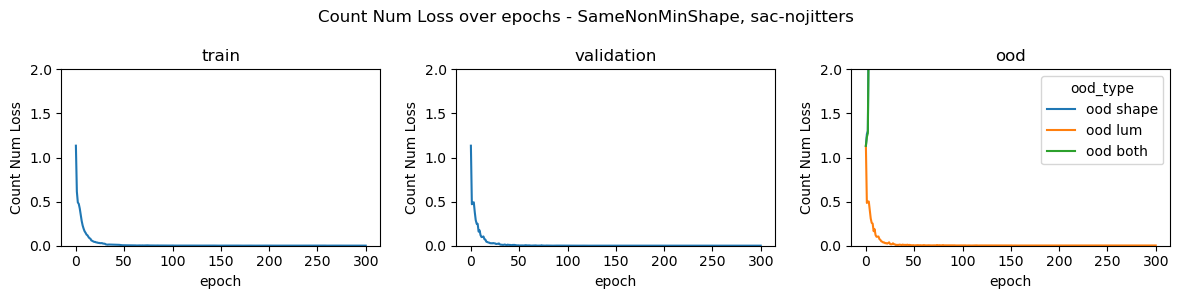

In [8]:
for rsname, res in res_lists.items():
    fig_acc, ax_acc = plt.subplots(1,3, figsize=(3*4, 3))
    for j, (ds, dsdf) in enumerate(res.groupby('dataset')):
        if ds == "ood":
            # further split by test shapes and lums
            dsdf = dsdf.copy()
            dsdf['test shapes ood'] = [s == "['C', 'F', 'G', 'H', 'J']" for s in dsdf['test shapes']]
            dsdf['test lums ood'] = [l == "[0.3, 0.6, 0.9]" for l in dsdf['test lums']]
            dsdf['ood_type'] = ["ood shape" if np.logical_and(s, not l) else
                                "ood lum" if np.logical_and(not s, l) else
                                "ood both" if np.logical_and(s, l) else
                                "iid" for s, l in zip(dsdf['test shapes ood'], dsdf['test lums ood'])]
            sns.lineplot(data=dsdf, x='epoch', y='count num loss', hue='ood_type', ax=ax_acc[j])

        else:
            sns.lineplot(data=dsdf, x='epoch', y='count num loss', ax=ax_acc[j])

        ax_acc[j].set_ylim(0, 2)
        ax_acc[j].set_title(ds)
        ax_acc[j].set_ylabel('Count Num Loss')

    fig_acc.suptitle(f'Count Num Loss over epochs - {rsname}')
    plt.tight_layout()

/tmp/ipykernel_124662/4246770285.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for j, (ds, dsdf) in enumerate(res.groupby('dataset')):
/tmp/ipykernel_124662/4246770285.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for j, (ds, dsdf) in enumerate(res.groupby('dataset')):


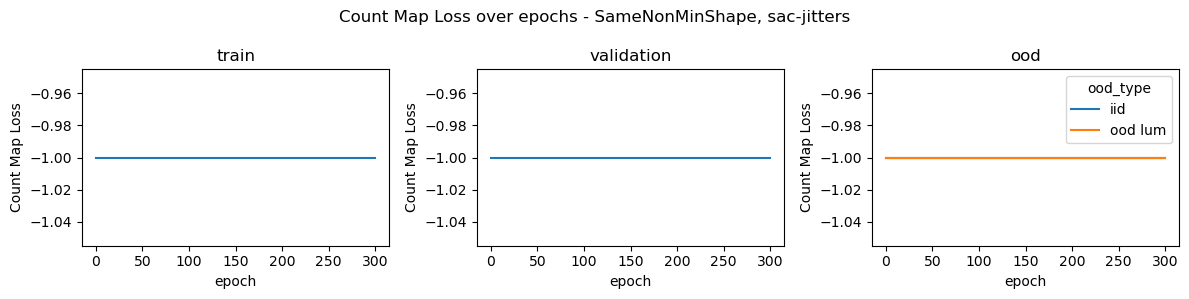

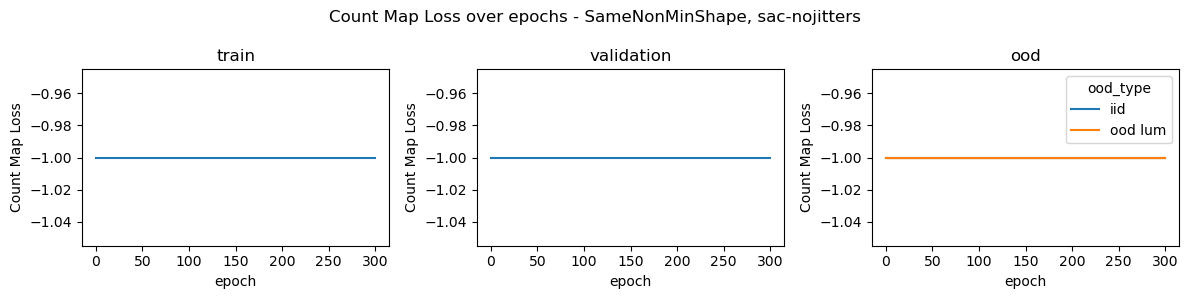

In [9]:
for rsname, res in res_lists.items():
    fig_acc, ax_acc = plt.subplots(1,3, figsize=(3*4, 3))
    for j, (ds, dsdf) in enumerate(res.groupby('dataset')):
        if ds == "ood":
            # further split by test shapes and lums
            dsdf = dsdf.copy()
            dsdf['test shapes ood'] = [s == "['F', 'G', 'H', 'J']" for s in dsdf['test shapes']]
            dsdf['test lums ood'] = [l == "[0.3, 0.6, 0.9]" for l in dsdf['test lums']]
            dsdf['ood_type'] = ["ood shape" if np.logical_and(s, not l) else
                                "ood lum" if np.logical_and(not s, l) else
                                "ood both" if np.logical_and(s, l) else
                                "iid" for s, l in zip(dsdf['test shapes ood'], dsdf['test lums ood'])]
            sns.lineplot(data=dsdf, x='epoch', y='count map loss', hue='ood_type', ax=ax_acc[j])

        else:
            sns.lineplot(data=dsdf, x='epoch', y='count map loss', ax=ax_acc[j])

        ax_acc[j].set_title(ds)
        ax_acc[j].set_ylabel('Count Map Loss')

    fig_acc.suptitle(f'Count Map Loss over epochs - {rsname}')
    plt.tight_layout()

In [10]:
f"{taskname}, sac-{saccond}"

'SameNonMinShape, sac-nojitters'

In [11]:
res_dfs_final_epoch = []
for rsname, res in res_lists.items():
    pattern = re.compile(r"(.*), sac-(.*)", re.IGNORECASE)
    match = pattern.search(rsname)
    taskname, saccond = match.group(1), match.group(2)

    res_final = res[res['epoch'] == res['epoch'].max()]
    res_final = res_final.copy()
    res_final['task'] = taskname
    res_final['saccond'] = saccond
    res_final["simname"] = f"num3-5_{saccond}"
    res_final['numrange'] = f"3-7"
    res_final['n_glimpses'] = 12

    print(res_final.shape)
    res_dfs_final_epoch.append(res_final)


(5, 21)
(5, 21)


In [12]:
res_final["dataset"]

300         train
300    validation
300           ood
300           ood
300           ood
Name: dataset, dtype: category
Categories (3, object): ['train' < 'validation' < 'ood']

/tmp/ipykernel_124662/2157686124.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for j, (taskname, taskdf) in enumerate(res_df_final_epoch.groupby('task')):
/tmp/ipykernel_124662/2157686124.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for k, (ds, dsdf) in enumerate(taskdf.groupby('dataset')):
/tmp/ipykernel_124662/2157686124.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for k, (ds, dsdf) in enumerate(

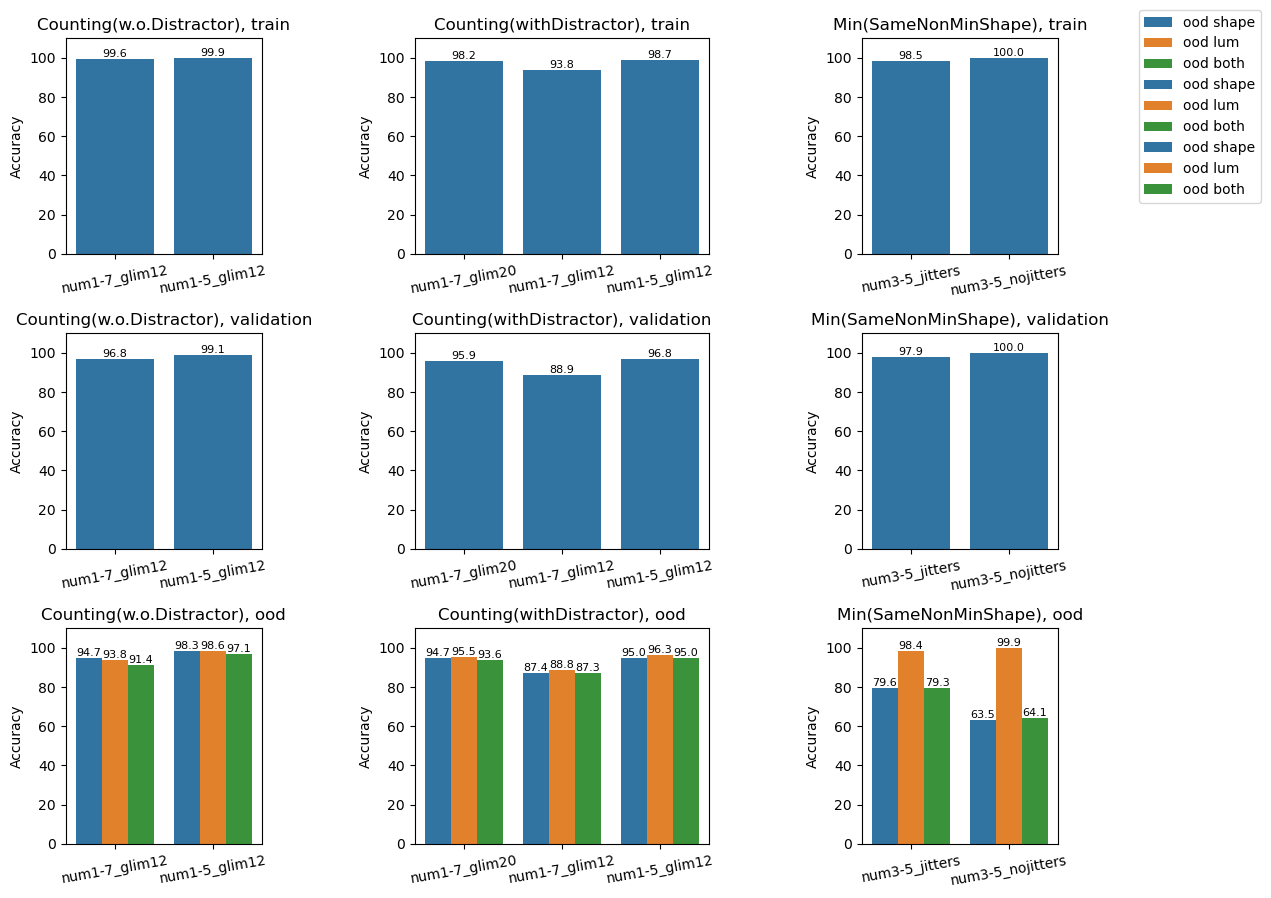

In [13]:
samminres_df_final_epoch = pd.concat(res_dfs_final_epoch).reset_index(drop=True)
ctrlres_df_final_epoch = pd.read_csv("saccade_models_final_epoch_results_2025Oct20.csv")
res_df_final_epoch = pd.concat([ctrlres_df_final_epoch, samminres_df_final_epoch]).reset_index(drop=True)
res_df_final_epoch["dataset"] = pd.Categorical(res_df_final_epoch["dataset"], categories = ["train","validation","ood"],ordered=True)
res_df_final_epoch["task"] = pd.Categorical(res_df_final_epoch["task"].map({'w.o. distractor':'Counting(w.o.Distractor)',
                                                                            'with distractor':'Counting(withDistractor)',
                                                                            'SameNonMinShape':'Min(SameNonMinShape)'}), 
                                            categories = ['Counting(w.o.Distractor)','Counting(withDistractor)',"Min(SameNonMinShape)"],ordered=True)
fig_acc, ax_acc = plt.subplots(3,3, figsize=(4*3, 3*3))
for j, (taskname, taskdf) in enumerate(res_df_final_epoch.groupby('task')):
    for k, (ds, dsdf) in enumerate(taskdf.groupby('dataset')):
        if ds == "ood":
            ood_shapes = "['C', 'F', 'G', 'H', 'J']" if taskname == "Min(SameNonMinShape)" else "['F', 'G', 'H', 'J']"
            # further split by test shapes and lums
            dsdf = dsdf.copy()
            dsdf['test shapes ood'] = [s == ood_shapes for s in dsdf['test shapes']]
            dsdf['test lums ood'] = [l == "[0.3, 0.6, 0.9]" for l in dsdf['test lums']]
            dsdf['ood_type'] = ["ood shape" if np.logical_and(s, not l) else
                                "ood lum" if np.logical_and(not s, l) else
                                "ood both" if np.logical_and(s, l) else
                                "iid" for s, l in zip(dsdf['test shapes ood'], dsdf['test lums ood'])]
            sns.barplot(data=dsdf, x='simname', y='accuracy count', hue='ood_type', ax=ax_acc[k,j])

        else:
            sns.barplot(data=dsdf, x='simname', y='accuracy count', ax=ax_acc[k,j])

        # Add labels (mean accuracy) on top of bars
        bars = sum([list(container) for container in ax_acc[k,j].containers], [])
        bhs  = sum([ [bar.get_height() for bar in container] for container in ax_acc[k,j].containers], [])
        #if max(bhs) - min(bhs) < 10:
        #    bhs = [np.mean(bhs) for _ in bhs]  # to avoid overlapping texts
        for i, (bar, height) in enumerate(zip(bars, bhs)):
            ax_acc[k,j].text(
                bar.get_x() + bar.get_width() / 2,
                height + 0.02, #+ i * 0.5,  # base offset above bar
                f"{height:.1f}",
                ha='center', va='bottom',
                fontsize=8,
            )


        ax_acc[k,j].set_ylim(0, 110)
        ax_acc[k,j].set_xlabel("")
        if j == 4:
            ax_acc[k,j].set_aspect(.02)
        else:
            ax_acc[k,j].set_aspect(.02)
            ax_acc[k,j].tick_params(axis='x', rotation=10)
        ax_acc[k,j].set_title(f"{taskname}, {ds}")
        ax_acc[k,j].set_ylabel('Accuracy')
        
            #fig_acc.delaxes(ax_acc[k,j])
    ax_acc[k,j].legend_.remove()

#for j in range(3):  
#    ax_acc[1,j].remove()
 
fig_acc.legend(bbox_to_anchor=(0.98, 1), loc='upper left')
fig_acc.tight_layout()
#sns.catplot(data=res_df_final_epoch, x='simname', y='accuracy count', hue='max_num',
#            col='task', row='dataset', kind='bar', height=4, aspect=1)


## confusion matrix

In [14]:
conf_dir = "Results_nojittersamenonminshape/results/logpolar"
conf_files = glob.glob(os.path.join(conf_dir, "confusion_*.npy"))
conf_files = [f for f in conf_files if "at_" not in f]
conf_files

['Results_nojittersamenonminshape/results/logpolar/confusion_pretrained_ventral-cnn-mse_hsize-1024_input-both_logpolar_num3-7_nl-0.74_policy-cheat+jitter_trainshapes-BCDE_min_logpolar_12_100000_loss-num_opt-Adam_drop0.5_sort_count-notA_300eps_rep0.npy']

In [15]:
for conf_file in conf_files:
    conf = np.load(conf_file)
    match = pattern.search(conf_file)
    res_name = ""
    if match:
        task_type = match.group(1)       # 'min' or 'max'
        loss_type = match.group(2)   # 'num'
        res_name = f"{task_type} task, {loss_type} loss"
        print(res_name)

In [16]:
res.viewing.unique()
conf.shape

(301, 4, 3, 3)

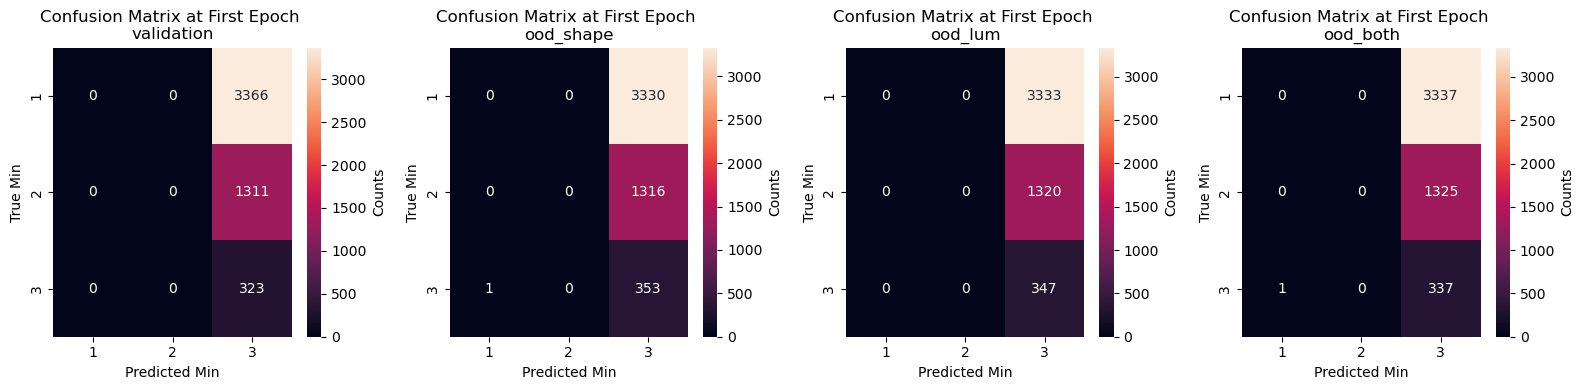

In [17]:
plt.subplots(1,4, figsize=(4*4,4))
# the four confusion matrices corresponded to: [val_free, ood_shape_free, ood_lum_free, ood_both_free]
conf_names = ['validation', 'ood_shape', 'ood_lum', 'ood_both']
for i, (cname,c) in enumerate(zip(conf_names,conf[0])):
    ax = plt.subplot(1, 4, i+1)
    sns.heatmap(c, annot=True, fmt=".0f", ax=ax, 
                cbar_kws={'label': 'Counts'},
                xticklabels=['1','2','3'],
                yticklabels=['1','2','3'])
    ax.set_title(f'Confusion Matrix at First Epoch \n{cname}')
    ax.set_xlabel('Predicted Min')
    ax.set_ylabel('True Min')

plt.tight_layout()

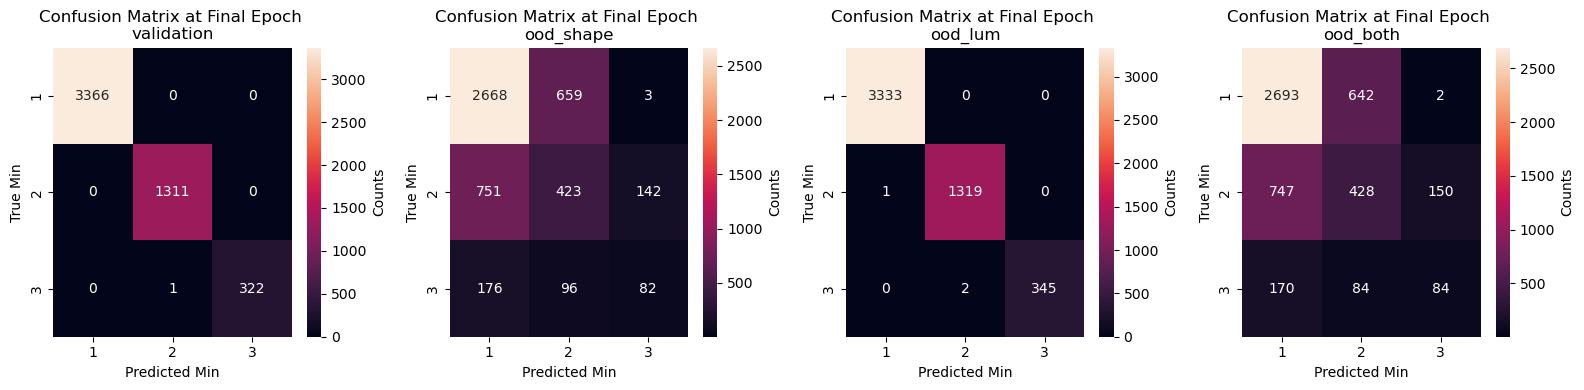

In [18]:
plt.subplots(1,4, figsize=(4*4,4))
# the four confusion matrices corresponded to: [val_free, ood_shape_free, ood_lum_free, ood_both_free]
conf_names = ['validation', 'ood_shape', 'ood_lum', 'ood_both']
for i, (cname,c) in enumerate(zip(conf_names,conf[-1])):
    ax = plt.subplot(1, 4, i+1)
    sns.heatmap(c, annot=True, fmt=".0f", ax=ax, 
                cbar_kws={'label': 'Counts'},
                xticklabels=['1','2','3'],
                yticklabels=['1','2','3'])
    ax.set_title(f'Confusion Matrix at Final Epoch \n{cname}')
    ax.set_xlabel('Predicted Min')
    ax.set_ylabel('True Min')

plt.tight_layout()

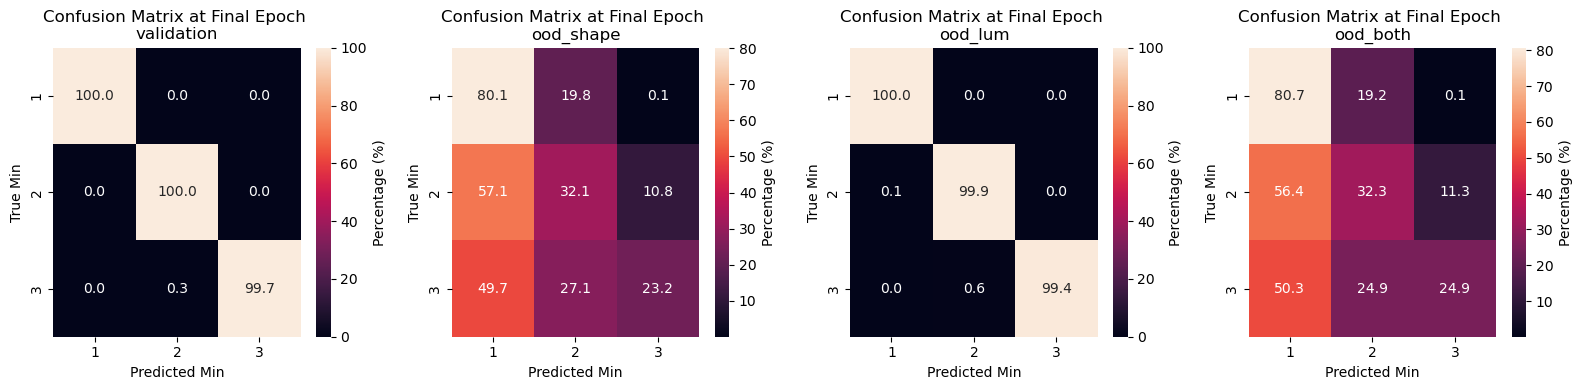

In [19]:
plt.subplots(1,4, figsize=(4*4,4))
# the four confusion matrices corresponded to: [val_free, ood_shape_free, ood_lum_free, ood_both_free]
conf_names = ['validation', 'ood_shape', 'ood_lum', 'ood_both']
for i, (cname,c) in enumerate(zip(conf_names,conf[-1])):
    ax = plt.subplot(1, 4, i+1)
    sns.heatmap(c*100 / c.sum(axis=1, keepdims=True), annot=True, fmt=".1f", ax=ax, 
                cbar_kws={'label': 'Percentage (%)'},
                xticklabels=['1','2','3'],
                yticklabels=['1','2','3'])
    ax.set_title(f'Confusion Matrix at Final Epoch \n{cname}')
    ax.set_xlabel('Predicted Min')
    ax.set_ylabel('True Min')

plt.tight_layout()

In [ ]:
#check the distribution of min values in the dataset
import xarray as xr
import os
import glob
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

ds_dir = "../minmaxdatasets"
ds_files = glob.glob(os.path.join(ds_dir, "*_40000.nc"))
ds_path = ds_files[0]
ds = xr.open_dataset(ds_path)

print(ds)

# plot the distribution of min values in the dataset
sns.histplot(ds["numerosity_min"].values)

vals, counts = np.unique(ds["numerosity_min"].values, return_counts=True)
counts/counts.sum()


# run a simulation to see if doing the inverse will give a uniform distribution
n_samples = 100000
probs = 1/ counts
probs = probs / probs.sum()
samples = np.random.choice(vals, size=n_samples, p=probs)
sns.histplot(samples)



/tmp/ipykernel_1581010/1483866307.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes_ill[1].set_xticklabels([' 4', '3', '2', '1 '])


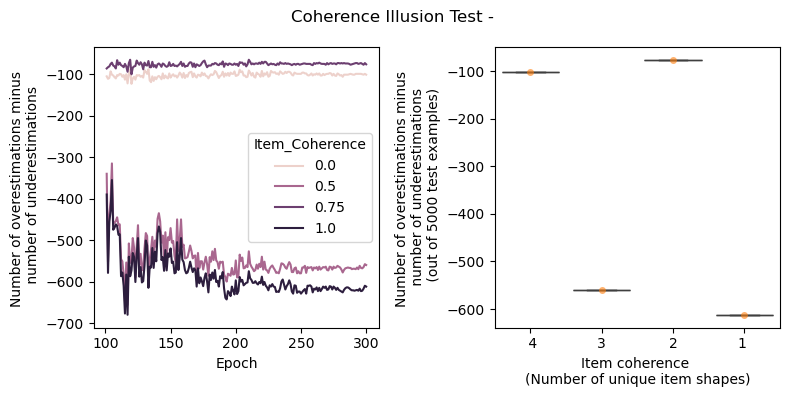

In [139]:
for conf_file in conf_files:
    conf = np.load(conf_file) # conf is of shape (n_epochs+1, 4, n_classes, n_classes)
    match = pattern.search(conf_file)
    res_name = ""
    if match:
        task_type = match.group(1)       # 'min' or 'max'
        loss_type = match.group(2)   # 'num'
        res_name = f"{task_type} task, {loss_type} loss"

    entries = []
    for ep, mat in enumerate(conf):
        # [diff1_loader, diff06_loader, diff03_loader, same_loader]
        diff_conf = mat[0, :, :]
        diff06_conf = mat[1, :, :]
        diff03_conf = mat[2, :, :]
        same_conf = mat[3, :, :]

        diffover = diff_conf[np.triu_indices_from(diff_conf, k=1)].sum()
        diffunder = diff_conf[np.tril_indices_from(diff_conf, k=-1)].sum()
        diff06over = diff06_conf[np.triu_indices_from(diff06_conf, k=1)].sum()
        diff06under = diff06_conf[np.tril_indices_from(diff06_conf, k=-1)].sum()
        diff03over = diff03_conf[np.triu_indices_from(diff03_conf, k=1)].sum()
        diff03under = diff03_conf[np.tril_indices_from(diff03_conf, k=-1)].sum()
        sameover = same_conf[np.triu_indices_from(same_conf, k=1)].sum()
        sameunder = same_conf[np.tril_indices_from(same_conf, k=-1)].sum()
        entries.append({'Item_Coherence':0, 'Over-Under': diffover-diffunder, 'Epoch':ep})
        entries.append({'Item_Coherence':2/4, 'Over-Under': diff06over-diff06under, 'Epoch':ep})
        entries.append({'Item_Coherence':3/4, 'Over-Under': diff03over-diff03under, 'Epoch':ep})
        entries.append({'Item_Coherence':1, 'Over-Under': sameover-sameunder, 'Epoch':ep})
    

    df = pd.DataFrame(entries)
    fig_ill, axes_ill = plt.subplots(1,2, figsize=(8,4))
    sns.lineplot(data=df[df.Epoch>100], y='Over-Under', x='Epoch', hue='Item_Coherence', ax=axes_ill[0])
    #axes_ill[0].set_title('Coherence Illusion Test')
    axes_ill[0].set_ylabel('Number of overestimations minus \n number of underestimations')

    last_epoch = df[df.Epoch==300]
    sns.boxplot(data=last_epoch, y='Over-Under', x='Item_Coherence', ax=axes_ill[1])
    sns.stripplot(data=last_epoch, y='Over-Under', x='Item_Coherence', ax=axes_ill[1], dodge=True, alpha=0.6)
    ticks = [-40, -20, 0, 20, 40]
    # ax.set_yticks(ticks, labels=[t/50 for t in ticks])
    axes_ill[1].set_ylabel('Number of overestimations minus \n number of underestimations \n (out of 5000 test examples)')
    # ax.set_title('Coherence illusion test')
    axes_ill[1].set_xlabel('Item coherence \n(Number of unique item shapes)')
    axes_ill[1].set_xticklabels([' 4', '3', '2', '1 '])

    fig_ill.suptitle(f'Coherence Illusion Test - {res_name}')
    plt.tight_layout()



##  Weights

In [14]:
import torch
from tensorly.decomposition import parafac, tucker
import tensortools as tt
model_dir = "models_SameNonMinShape/logpolar"
model_file = [x for x in glob.glob(os.path.join(model_dir, "pretrained_ventral*.pt")) if "loss-num" in x][0]
print(model_file)
ventral_model_file = glob.glob(os.path.join(model_dir,"ventral","*.pt"))[0]
print(ventral_model_file)
saved_model = torch.load(model_file)
saved_model

models_SameNonMinShape/logpolar/pretrained_ventral-cnn-mse_hsize-1024_input-both_logpolar_num3-7_nl-0.74_policy-cheat+jitter_trainshapes-BCDE_min_logpolar_12_100000_loss-num_opt-Adam_drop0.5_sort_count-notA_300eps_rep0_ep-300.pt
models_SameNonMinShape/logpolar/ventral/ventral_cnn-lrelu_hsize-25_logpolar_num3-7_nl-0.74_diff-0-6_grid6_policy-cheat+jitter_lum-[0.1, 0.4, 0.7, 0.3, 0.6, 0.9]_trainshapes-BCDEFGHJ__logpolar_40000_loss-mse_opt-Adam_drop0.4_200eps_rep0_ep-200.pt


/tmp/ipykernel_124662/3213158937.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  saved_model = torch.load(model_file)


PretrainedVentral(
  (ventral): ConvNet(
    (LReLU): LeakyReLU(negative_slope=0.1)
    (conv1): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1))
    (conv2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (conv3): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (fc1): Linear(in_features=15120, out_features=50, bias=True)
    (fc2): Linear(in_features=50, out_features=10, bias=True)
    (fc3): Linear(in_features=10, out_features=8, bias=True)
    (drop_layer): Dropout(p=0.4, inplace=False)
  )
  (rnn): RNNClassifier2stream(
    (pix_embedding): Linear(in_features=10, out_features=512, bias=True)
    (xy_embedding): Linear(in_features=2, out_features=512, bias=True)
    (joint_embedding): Linear(in_features=1024, out_features=1024, bias=True)
    (rnn): RNN(
      (act_fun): LeakyReLU(negative_slope=0.1)
      (i2h): Linear(in_features=2048, out_features=1024, bias=True)
      (h2o): Linear(in_features=1024, out_features=1024, bias=True)
    )
    (drop_layer): Dropout(p=0.

In [15]:
model_weights = {}
print("\nModel parameter summary (name, shape, L2 norm):")
for name, p in saved_model.named_parameters():
    print(f"{name} {tuple(p.shape)}  L2={p.detach().cpu().norm().item():.4f}")
    model_weights[name] = p.detach().cpu().numpy()


Model parameter summary (name, shape, L2 norm):
ventral.conv1.weight (10, 1, 3, 3)  L2=2.4472
ventral.conv1.bias (10,)  L2=0.3970
ventral.conv2.weight (10, 10, 3, 3)  L2=8.7511
ventral.conv2.bias (10,)  L2=0.7439
ventral.conv3.weight (10, 10, 3, 3)  L2=7.7365
ventral.conv3.bias (10,)  L2=0.4624
ventral.fc1.weight (50, 15120)  L2=141.5242
ventral.fc1.bias (50,)  L2=6.1466
ventral.fc2.weight (10, 50)  L2=6.7642
ventral.fc2.bias (10,)  L2=0.6917
ventral.fc3.weight (8, 10)  L2=3.3103
ventral.fc3.bias (8,)  L2=0.0614
rnn.pix_embedding.weight (512, 10)  L2=14.2205
rnn.pix_embedding.bias (512,)  L2=3.8185
rnn.xy_embedding.weight (512, 2)  L2=11.8704
rnn.xy_embedding.bias (512,)  L2=7.2414
rnn.joint_embedding.weight (1024, 1024)  L2=47.7785
rnn.joint_embedding.bias (1024,)  L2=0.6877
rnn.rnn.i2h.weight (1024, 2048)  L2=70.7471
rnn.rnn.i2h.bias (1024,)  L2=1.1879
rnn.rnn.h2o.weight (1024, 1024)  L2=59.2129
rnn.rnn.h2o.bias (1024,)  L2=1.6825
rnn.map_readout.weight (36, 1024)  L2=6.6910
rnn.map

Text(0.5, 1.0, 'First 3 Principal Components of Input-Hidden Weights')

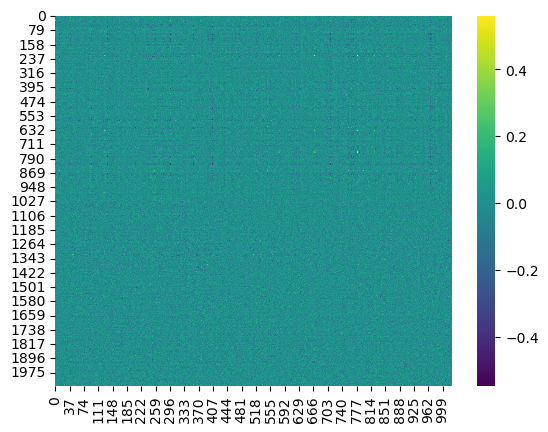

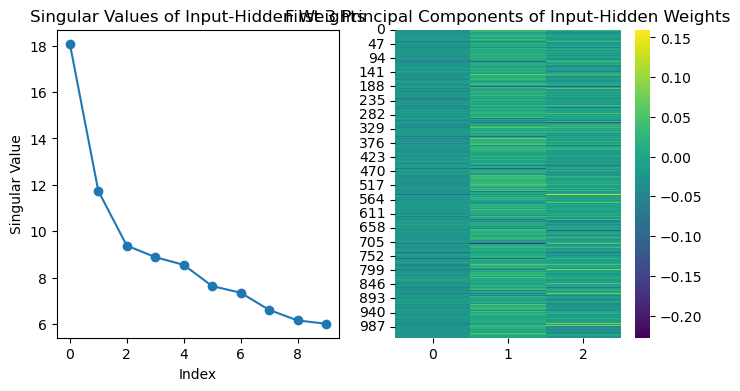

In [16]:
sns.heatmap(model_weights['rnn.rnn.i2h.weight'].T, cmap='viridis')
# perform svd on the input-hidden weights
U, S, Vt = np.linalg.svd(model_weights['rnn.rnn.i2h.weight'], full_matrices=False)
plt.figure(figsize=(8,4))
# plot the singular values (only first 10)
plt.subplot(1,2,1)
plt.plot(S[:10], marker='o')
plt.title('Singular Values of Input-Hidden Weights')
plt.xlabel('Index')
plt.ylabel('Singular Value')
# plot the first 3 PCs in heatmap
plt.subplot(1,2,2)
sns.heatmap(U[:,:3], cmap='viridis')
plt.title('First 3 Principal Components of Input-Hidden Weights')

## Activations

In [15]:
actv_dir = "activations_SameNonMinShape/activations_SameNonMinShape"
actv_dir = "activations"
actv_files = glob.glob(os.path.join(actv_dir, "*trained_test-new_both.npz"))
actv_file = [x for x in actv_files if "num1-5" in x][0]
print(actv_file)
activation_data = np.load(actv_file,allow_pickle=True)

print(list(activation_data.keys()))

for k,v in activation_data.items():
    print(k, v.shape)

activations/rnn_classifier2stream_hsize-1024_input-both_logpolar_num1-5_nl-0.74_policy-cheat+jitter_trainshapes-BCDEsame__logpolar_12_100000_loss-both_opt-Adam_drop0.5_sort_count-notA_300eps_rep0_trained_test-new_both.npz
['numerosity', 'num_distractor', 'act_hidden', 'predicted_num', 'correct', 'glimpse_xy', 'target_locations', 'distractor_locations']
numerosity (5000,)
num_distractor (5000,)
act_hidden (5000, 12, 1024)
predicted_num (5000, 5)
correct (5000,)
glimpse_xy (5000, 12, 2)
target_locations (5000,)
distractor_locations (5000, 0)


In [129]:
X.shape

(1024, 12, 5000)

In [80]:
ensemble = tt.Ensemble(fit_method="ncp_hals")
from sklearn.metrics import r2_score
# do in cv
X = activation_data["act_hidden"].copy().T
ensemble.fit(X, ranks=range(1,9), replicates=1)


Rank-1 models:  min obj, 0.94;  max obj, 0.94;  time to fit, 13.3s


Rank-2 models:  min obj, 0.89;  max obj, 0.89;  time to fit, 10.8s


Rank-3 models:  min obj, 0.87;  max obj, 0.87;  time to fit, 29.5s


Rank-4 models:  min obj, 0.86;  max obj, 0.86;  time to fit, 38.6s


Rank-5 models:  min obj, 0.85;  max obj, 0.85;  time to fit, 51.4s


Rank-6 models:  min obj, 0.84;  max obj, 0.84;  time to fit, 29.9s


Rank-7 models:  min obj, 0.83;  max obj, 0.83;  time to fit, 20.2s


Rank-8 models:  min obj, 0.82;  max obj, 0.82;  time to fit, 43.7s


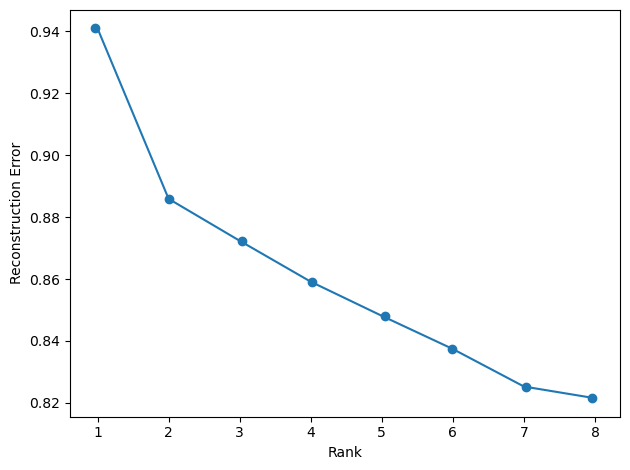

In [81]:
fig,ax = plt.subplots(1,1)
tt.plot_objective(ensemble, ax=ax)
ax.set_xlabel('Rank')
ax.set_ylabel('Reconstruction Error')
fig.tight_layout()

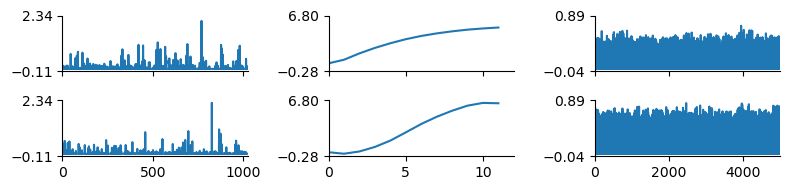

In [82]:
num_components = 2
replicate = 0
tt.plot_factors(ensemble.factors(num_components)[replicate])
plt.show()

In [ ]:
list(activation_data.keys())
#  'numerosity', (5000,)
#  'num_distractor', (5000,)
#  'act_hidden', (5000, 12, 1024)
#  'predicted_num', (5000, 5)
#  'correct',  (5000,)
#  'glimpse_xy', (5000, 12, 2)
#  'target_locations', (5000,)
#  'distractor_locations' (5000, 0)


['numerosity',
 'num_distractor',
 'act_hidden',
 'predicted_num',
 'correct',
 'glimpse_xy',
 'target_locations',
 'distractor_locations']

In [118]:
df

,numerosity,num_distractor,correct
0,2.0,0.0,1.0
1,1.0,0.0,1.0
2,3.0,0.0,1.0
3,2.0,0.0,1.0
4,4.0,0.0,1.0
...,...,...,...
4995,4.0,0.0,1.0
4996,2.0,0.0,1.0
4997,2.0,0.0,1.0
4998,4.0,0.0,1.0


In [139]:
X[neuron_selector][:,:,trial_selector].shape

(217, 12, 4857)

0.0 2.2329923587029477
0.0 2.2329923587029477


/tmp/ipykernel_124662/3768520595.py:58: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


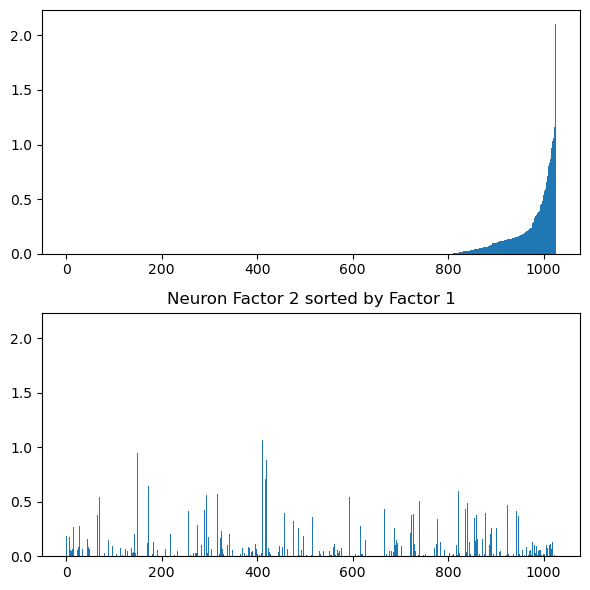

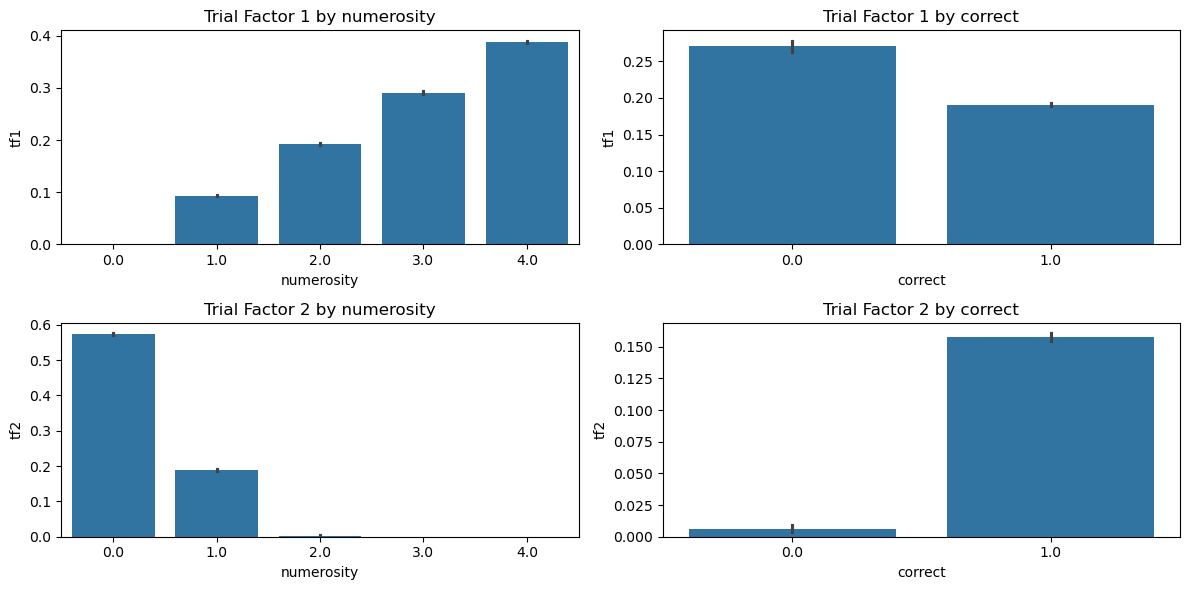

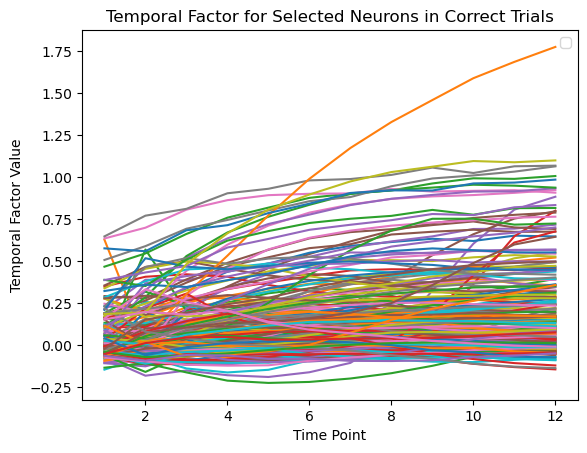

In [140]:
# sort neuron by index
import numpy as np
num_components = 2
replicate = 0
sort_by = 0
plotU = ensemble.factors(num_components)[replicate]
neuron_factors = plotU[0] # first factor corresponds to neurons
sorted_indices = np.argsort(neuron_factors[:,sort_by])

temporal_factors = plotU[1] # second factor corresponds to time
trial_factors = plotU[2]    # third factor corresponds to trials



fig, axes = plt.subplots(plotU.rank, 1, figsize=(6*1, 3*plotU.rank))
for r in range(plotU.rank):
    #for i,f in enumerate(plotU):
    print(np.min(neuron_factors), np.max(neuron_factors))
    x = np.arange(1, neuron_factors.shape[0]+1)
    axes[r].bar(x, neuron_factors[:, r][sorted_indices],width=2.0)
    axes[r].set_ylim(np.min(neuron_factors), np.max(neuron_factors))
    if r == plotU.rank - 1:
        axes[r].set_title(f'Neuron Factor {r+1} sorted by Factor {sort_by+1}')
    else:
        axes[r].set_title(f'')
plt.tight_layout()



df = pd.DataFrame({
    "numerosity": activation_data["numerosity"],
    "num_distractor": activation_data["num_distractor"],
    "correct": activation_data["correct"]
})
for idx in range(trial_factors.shape[1]):
    df[f"tf{idx+1}"] = trial_factors[:, idx]

xvars = ['numerosity', 'correct']
fig, axes = plt.subplots(plotU.rank, len(xvars), figsize=(6*len(xvars), 3*plotU.rank))
for r in range(plotU.rank):
    for c, xvar in enumerate(xvars):
        sns.barplot(data=df, x=xvar, y=f'tf{r+1}', ax=axes[r, c],errorbar='se')
        axes[r, c].set_title(f'Trial Factor {r+1} by {xvar}')
plt.tight_layout()

fig, ax = plt.subplots(1,1)
neuron_selector = neuron_factors[:,sort_by] > 0
trial_selector  = activation_data["correct"] == 1
# plot average activity for selected neurons in selected trials
mean_temporal = X[neuron_selector][:,:,trial_selector].mean(axis=2)
#std_temporal = X[neuron_selector][:,:,trial_selector].std(axis=2)
time_points = np.arange(1, temporal_factors.shape[0]+1)
for mt in mean_temporal:
    ax.plot(time_points, mt)
ax.set_title('Temporal Factor for Selected Neurons in Correct Trials')
ax.set_xlabel('Time Point')
ax.set_ylabel('Temporal Factor Value')
ax.legend()



In [78]:
for i,f in enumerate(ensemble.factors(num_components)[replicate]):
    print(f"Factor {i} shape: {f.shape}")
    print(f"Factor {i} max: {f.max()}, min: {f.min()}")

Factor 0 shape: (1024, 2)
Factor 0 max: 2.3012517589007837, min: 0.0
Factor 1 shape: (12, 2)
Factor 1 max: 6.33727270694479, min: 0.04160076200908575
Factor 2 shape: (5000, 2)
Factor 2 max: 0.8388415163824755, min: 0.0


In [61]:
ensemble.factors(num_components)[replicate][0].shape

(1024, 2)

In [63]:
ensemble.factors(num_components)[replicate][0].max()

np.float64(2.3012517589007837)

Text(0.5, 1.0, 'Neurons in 2D space defined by first two TCA components')

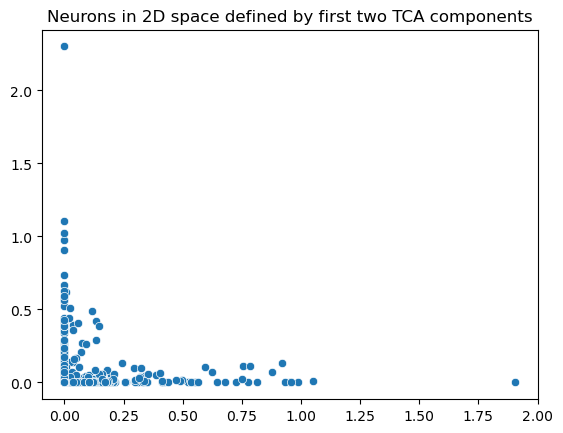

In [49]:
# plot neurons in the 2D space defined by first two components
neuron_locs = ensemble.factors(num_components)[replicate][0]
sns.scatterplot(x=neuron_locs[:,0], y=neuron_locs[:,1])
plt.title('Neurons in 2D space defined by first two TCA components')

## Cross-validated TCA

In [66]:
# load result of CV TCA
from joblib import load

TCAres_files = {
    "counting_min1max5":   "TCAres_counting_min1max5.pkl",
    "counting_min1max7":   "TCAres_counting_min1max7.pkl",
    "samenonmin_min3max7": "TCAres_samenonmin_min3max7.pkl"
}
TCAres = {key: load(filename) for key, filename in TCAres_files.items()}

In [71]:
print(TCAres["samenonmin_min3max7"].keys())
TCAres["samenonmin_min3max7"]["R"]

dict_keys(['train_err', 'test_err', 'U', 'R', 'train_r2', 'test_r2'])


[1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29]

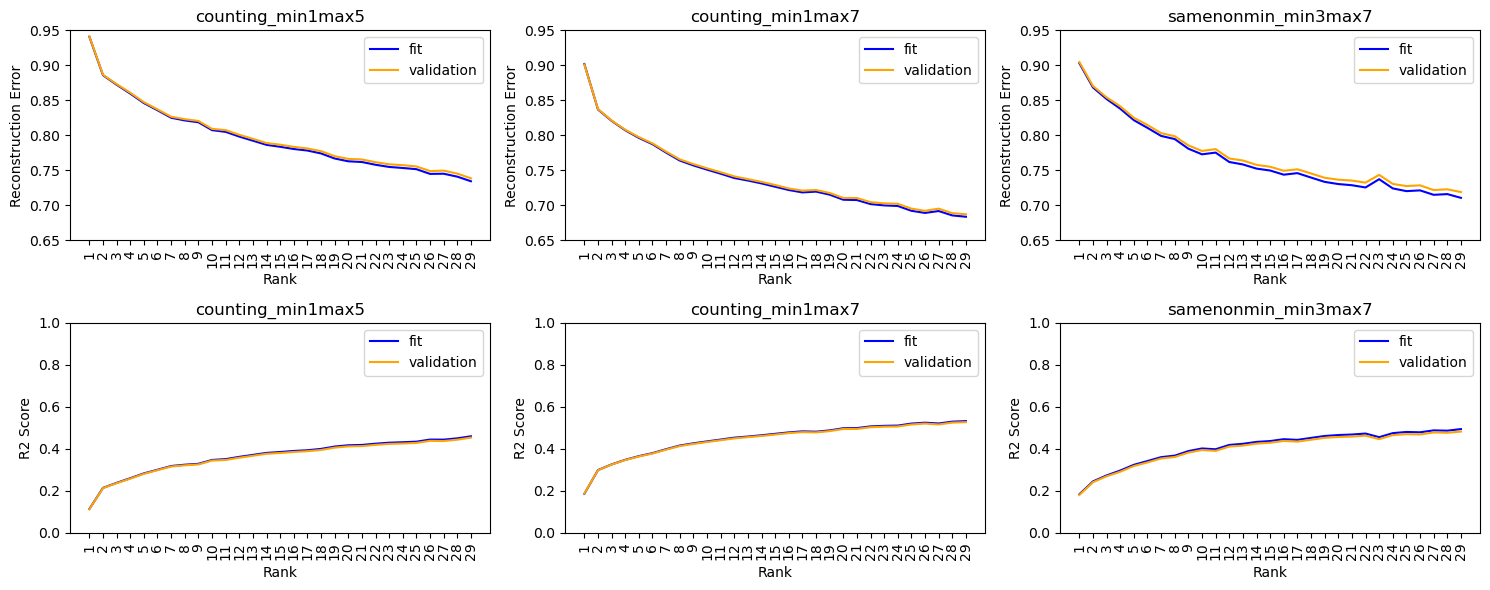

In [75]:
ncol = len(TCAres)
yvars = ["err","r2"]
fig,axes = plt.subplots(2,ncol, figsize=(5*ncol,3*2))
for i, (simname, res) in enumerate(TCAres.items()):
    for j, yvar in enumerate(yvars):
        axes[j,i].plot(res[f'train_{yvar}'], label="fit", color='blue')
        axes[j,i].plot(res[f'test_{yvar}'], label="validation", color='orange')
        axes[j,i].set_title(simname)
        axes[j,i].set_xticks(np.arange(len(res['R'])),res['R'],rotation=90)
        axes[j,i].set_xlabel('Rank')
        axes[j,i].legend()
        if yvar == "err":
            axes[j,i].set_ylabel('Reconstruction Error')
            axes[j,i].set_ylim(0.65,0.95)
        else:
            axes[j,i].set_ylabel('R2 Score')
            axes[j,i].set_ylim(0.0,1.0)
fig.tight_layout()